# 01 - H&E Registration to Xenium Morphology with Palom

This notebook registers H&E to Xenium morphology for the two tutorial samples `AP0921a` and `AP2320a`. The input table is `config/samples.tsv`, with one H&E OME-TIFF and one Xenium morphology OME-TIFF per sample.

Palom is used because this tutorial needs a reproducible whole-slide registration step that writes registered H&E into Xenium pixel coordinates. The full-slide overlay QC at the end is meant to answer a practical question before downstream morphology analysis: are the registered H&E and Xenium morphology images globally aligned well enough to extract cell-centered H&E patches? Cell boundaries are not used in this notebook; Notebooks 2 and 3 use Cellpose `cell_boundaries.csv.gz` from the Xenium-format Cellpose export.

## 0. Palom environment and installation

Notebook 1 needs Palom for registration. The Palom project recommends a fresh Python 3.10 conda environment:

```bash
conda create -n palom python=3.10
conda activate palom
python -m pip install 'palom[all]'
python -m pip install ipykernel
python -m ipykernel install --user --name palom --display-name "Palom registration"
```

Official Palom reference: https://github.com/labsyspharm/palom/tree/main

For this packaged tutorial, the registration input images are copied under `input/registration/` and listed in `config/samples.tsv`. The Palom Python executable is resolved in this order:

1. `PALOM_PYTHON` environment variable, if set.
2. A project-local `./.venv-palom/bin/python`, if present.
3. The current notebook Python executable.

The notebook kernel itself only needs lightweight packages for reading config tables, launching the Palom script, and displaying QC figures. The executable used for the Palom command must have `palom[all]` installed.

In [1]:
import importlib.util
import shutil
import sys

required_python = ['numpy', 'pandas', 'tifffile', 'yaml', 'matplotlib']
missing = [pkg for pkg in required_python if importlib.util.find_spec(pkg) is None]
print('Notebook Python:', sys.executable)
print('Missing notebook packages:', missing if missing else 'none')
print('Rscript:', shutil.which('Rscript') or 'not found')

Notebook Python: <PROJECT>/.venv/bin/python
Missing notebook packages: none
Rscript: /usr/bin/Rscript


In [2]:
from pathlib import Path
import json
import os
import sys
import shutil
import subprocess

import pandas as pd
import yaml
from IPython.display import Image, display

def find_project_dir() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'config/tutorial_paths.yaml').exists():
            return candidate
    raise RuntimeError('Could not find project root containing config/tutorial_paths.yaml')

def project_path(value) -> Path:
    p = Path(value)
    return p if p.is_absolute() else PROJECT / p

def resolve_common_paths(cfg: dict) -> dict:
    for key in ['registration_sample_table', 'cellpose_sample_table', 'hoptimus_cellpose_config', 'input_dir', 'seurat_rds', 'subtype_reference_dir']:
        if key in cfg and cfg[key] is not None:
            cfg[key] = str(project_path(cfg[key]))
    if 'results' in cfg:
        cfg['results'] = {k: str(project_path(v)) for k, v in cfg['results'].items()}
    return cfg

PROJECT = find_project_dir()
CONFIG = PROJECT / 'config/tutorial_paths.yaml'
cfg = resolve_common_paths(yaml.safe_load(CONFIG.read_text()))
sample_table_path = Path(cfg.get('registration_sample_table', cfg.get('sample_table')))
samples = pd.read_csv(sample_table_path, sep='	', keep_default_na=False)
for col in ['he_ome_tif', 'xenium_morphology_ome_tif']:
    samples[col] = samples[col].map(lambda x: str(project_path(x)))
registration_samples = cfg['parameters'].get('registration_samples', cfg['parameters'].get('samples', []))
samples = samples[samples['sample_id'].astype(str).isin(registration_samples)].reset_index(drop=True)
palom_work = Path(cfg['results']['palom'])
print('Palom results:', palom_work)
print('Registration sample table:', sample_table_path)
display(samples)

Palom results: <PROJECT>/results/01_palom_registration
Registration sample table: <PROJECT>/config/samples.tsv


,sample_id,he_ome_tif,xenium_morphology_ome_tif
0,AP0921a,/inp...,/inp...
1,AP2320a,/inp...,/inp...


## 1. Validate tutorial inputs

Each registration row must contain an H&E OME-TIFF and a Xenium morphology OME-TIFF. These are the only inputs used by this notebook.

In [3]:
manifest = {'config': str(CONFIG), 'registration_sample_table': str(sample_table_path), 'samples': []}
required_cols = ['he_ome_tif', 'xenium_morphology_ome_tif']
for row in samples.to_dict('records'):
    item = {'sample_id': row['sample_id']}
    for col in required_cols:
        path = Path(row[col])
        item[col] = str(path)
        item[f'{col}_exists'] = path.exists()
        item[f'{col}_size_bytes'] = path.stat().st_size if path.exists() else None
    manifest['samples'].append(item)
manifest['all_required_inputs_exist'] = all(
    item[f'{col}_exists'] for item in manifest['samples'] for col in required_cols
)
(palom_work / 'tables').mkdir(parents=True, exist_ok=True)
(palom_work / 'input_manifest.json').write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))
assert manifest['all_required_inputs_exist'], 'Missing required H&E or Xenium morphology inputs; inspect manifest above.'

{
  "config": "<PROJECT>/config/tutorial_paths.yaml",
  "registration_sample_table": "<PROJECT>/config/samples.tsv",
  "samples": [
    {
      "sample_id": "AP0921a",
      "he_ome_tif": "<PROJECT>/input/registration/AP0921a/AP0921a H and E pf 40x.ome.tif",
      "he_ome_tif_exists": true,
      "he_ome_tif_size_bytes": 187005318,
      "xenium_morphology_ome_tif": "<PROJECT>/input/registration/AP0921a/AP0921a_morphology_focus_0000.ome.tif",
      "xenium_morphology_ome_tif_exists": true,
      "xenium_morphology_ome_tif_size_bytes": 433559877
    },
    {
      "sample_id": "AP2320a",
      "he_ome_tif": "<PROJECT>/input/registration/AP2320a/AP2320a H and E pf 40x.ome.tif",
      "he_ome_tif_exists": true,
      "he_ome_tif_size_bytes": 141918409,
      "xenium_morphology_ome_tif": "<PROJECT>/input/registration/AP2320a/AP2320a_morphology_focus_0000.ome.tif",
      "xenium_morphology_ome_tif_exists": true,
      "xenium_morphology_ome_tif_size_bytes": 308517481
    }
  ],
  "all_requi

## 2. Run Palom registration

The local Palom runner registers the H&E hematoxylin signal to the Xenium DAPI channel, computes local block affine correction, and writes a pyramidal registered H&E OME-TIFF. Outputs are stored under `results/01_palom_registration/outputs/<sample>/registered_slides/`.

In [4]:
palom_python_env = os.environ.get('PALOM_PYTHON')
if palom_python_env:
    palom_python = palom_python_env
elif (PROJECT / '.venv-palom/bin/python').exists():
    palom_python = str(PROJECT / '.venv-palom/bin/python')
else:
    palom_python = sys.executable
print('Using Python for Palom:', palom_python)
run_summary = []
for row in samples.to_dict('records'):
    sample = row['sample_id']
    outdir = palom_work / 'outputs' / sample / 'registered_slides'
    outdir.mkdir(parents=True, exist_ok=True)
    out_name = f'{sample}_he_registered_palom.ome.tif'
    out_path = outdir / out_name
    overlay_path = outdir / f'{sample}_he_registered_palom_overlay.png'
    cmd = [
        palom_python, str(PROJECT / 'scripts/palom/palom_register_he_to_dapi.py'),
        '--he-path', row['he_ome_tif'],
        '--dapi-path', row['xenium_morphology_ome_tif'],
        '--out-dir', str(outdir),
        '--out-name', out_name,
        '--dapi-channel', str(cfg['parameters']['palom_dapi_channel']),
        '--overlay-out', str(overlay_path),
        '--xe-force',
    ]
    if out_path.exists() and out_path.stat().st_size > 0:
        print(f'Reusing existing Palom registration: {out_path}')
    else:
        print(' '.join(cmd))
        subprocess.run(cmd, cwd=PROJECT, check=True, env={**os.environ, 'MPLBACKEND': 'Agg'})
    run_summary.append({
        'sample_id': sample,
        'registered_he': str(out_path),
        'overlay': str(overlay_path),
        'exists': out_path.exists(),
        'reused_if_present': True,
    })
(palom_work / 'outputs/palom_run_summary.json').parent.mkdir(parents=True, exist_ok=True)
(palom_work / 'outputs/palom_run_summary.json').write_text(json.dumps(run_summary, indent=2))
print(json.dumps(run_summary, indent=2))


Using Python for Palom: <PROJECT>/.venv/bin/python
Reusing existing Palom registration: <PROJECT>/results/01_palom_registration/outputs/AP0921a/registered_slides/AP0921a_he_registered_palom.ome.tif
Reusing existing Palom registration: <PROJECT>/results/01_palom_registration/outputs/AP2320a/registered_slides/AP2320a_he_registered_palom.ome.tif
[
  {
    "sample_id": "AP0921a",
    "registered_he": "<PROJECT>/results/01_palom_registration/outputs/AP0921a/registered_slides/AP0921a_he_registered_palom.ome.tif",
    "overlay": "<PROJECT>/results/01_palom_registration/outputs/AP0921a/registered_slides/AP0921a_he_registered_palom_overlay.png",
    "exists": true,
    "reused_if_present": true
  },
  {
    "sample_id": "AP2320a",
    "registered_he": "<PROJECT>/results/01_palom_registration/outputs/AP2320a/registered_slides/AP2320a_he_registered_palom.ome.tif",
    "overlay": "<PROJECT>/results/01_palom_registration/outputs/AP2320a/registered_slides/AP2320a_he_registered_palom_overlay.png",
  

## 3. Export registered H&E paths

This manifest records stable symlinks to the Palom registered H&E images. Notebook 2 uses the registered H&E paths listed in `config/cellpose_samples.tsv`; after a fresh Notebook 1 registration, update that table if you want Notebook 2 to consume these newly written files.

In [5]:
registered_dir = palom_work / 'registered_he'
registered_dir.mkdir(parents=True, exist_ok=True)
registered_manifest = []
for row in samples.to_dict('records'):
    sample = row['sample_id']
    src = palom_work / 'outputs' / sample / 'registered_slides' / f'{sample}_he_registered_palom.ome.tif'
    dst = registered_dir / src.name
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    os.symlink(src, dst)
    registered_manifest.append({'sample_id': sample, 'registered_he': str(dst), 'source': str(src)})
(palom_work / 'registered_he_manifest.json').write_text(json.dumps(registered_manifest, indent=2))
print(json.dumps(registered_manifest, indent=2))

[
  {
    "sample_id": "AP0921a",
    "registered_he": "<PROJECT>/results/01_palom_registration/registered_he/AP0921a_he_registered_palom.ome.tif",
    "source": "<PROJECT>/results/01_palom_registration/outputs/AP0921a/registered_slides/AP0921a_he_registered_palom.ome.tif"
  },
  {
    "sample_id": "AP2320a",
    "registered_he": "<PROJECT>/results/01_palom_registration/registered_he/AP2320a_he_registered_palom.ome.tif",
    "source": "<PROJECT>/results/01_palom_registration/outputs/AP2320a/registered_slides/AP2320a_he_registered_palom.ome.tif"
  }
]


## 4. Create Palom overlay QC figures

Full-slide overlays check global registration. Zoomed tile overlays are intentionally not generated in this tutorial version because the full overlay is more stable for notebook-level review.


In [6]:
fig_dir = palom_work / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
for stale in fig_dir.glob('*_palom_overlay_tile*.png'):
    stale.unlink()
PLOT_PYTHON = PROJECT / '.venv/bin/python'
plot_python = str(PLOT_PYTHON) if PLOT_PYTHON.exists() else sys.executable
cmd = [
    plot_python, str(PROJECT / 'scripts/plotting/plot_palom_registration_qc.py'),
    '--config', str(CONFIG),
    '--registered-dir', str(registered_dir),
    '--outdir', str(fig_dir),
    '--tile-size', str(cfg['parameters']['overlay_tile_size_px']),
    '--tile-count', '0',
    '--tile-zoom-factor', '8',
    '--seed', str(cfg['parameters']['random_seed']),
]
print(' '.join(cmd))
subprocess.run(cmd, cwd=PROJECT, check=True, env={**os.environ, 'MPLBACKEND': 'Agg'})
print('Wrote Palom full-overlay QC figures to', fig_dir)


<PROJECT>/.venv/bin/python <PROJECT>/scripts/plotting/plot_palom_registration_qc.py --config <PROJECT>/config/tutorial_paths.yaml --registered-dir <PROJECT>/results/01_palom_registration/registered_he --outdir <PROJECT>/results/01_palom_registration/figures --tile-size 1024 --tile-count 0 --tile-zoom-factor 8 --seed 42


wrote <PROJECT>/results/01_palom_registration/figures/palom_registration_qc_manifest.json
Wrote Palom full-overlay QC figures to <PROJECT>/results/01_palom_registration/figures


## 5. Display generated QC figures

**AP0921a full-slide Palom overlay QC**

The embedded image below is a lightweight thumbnail for GitHub rendering. The full-resolution overlay is written locally to `results/01_palom_registration/figures/AP0921a_palom_full_overlay.png`.

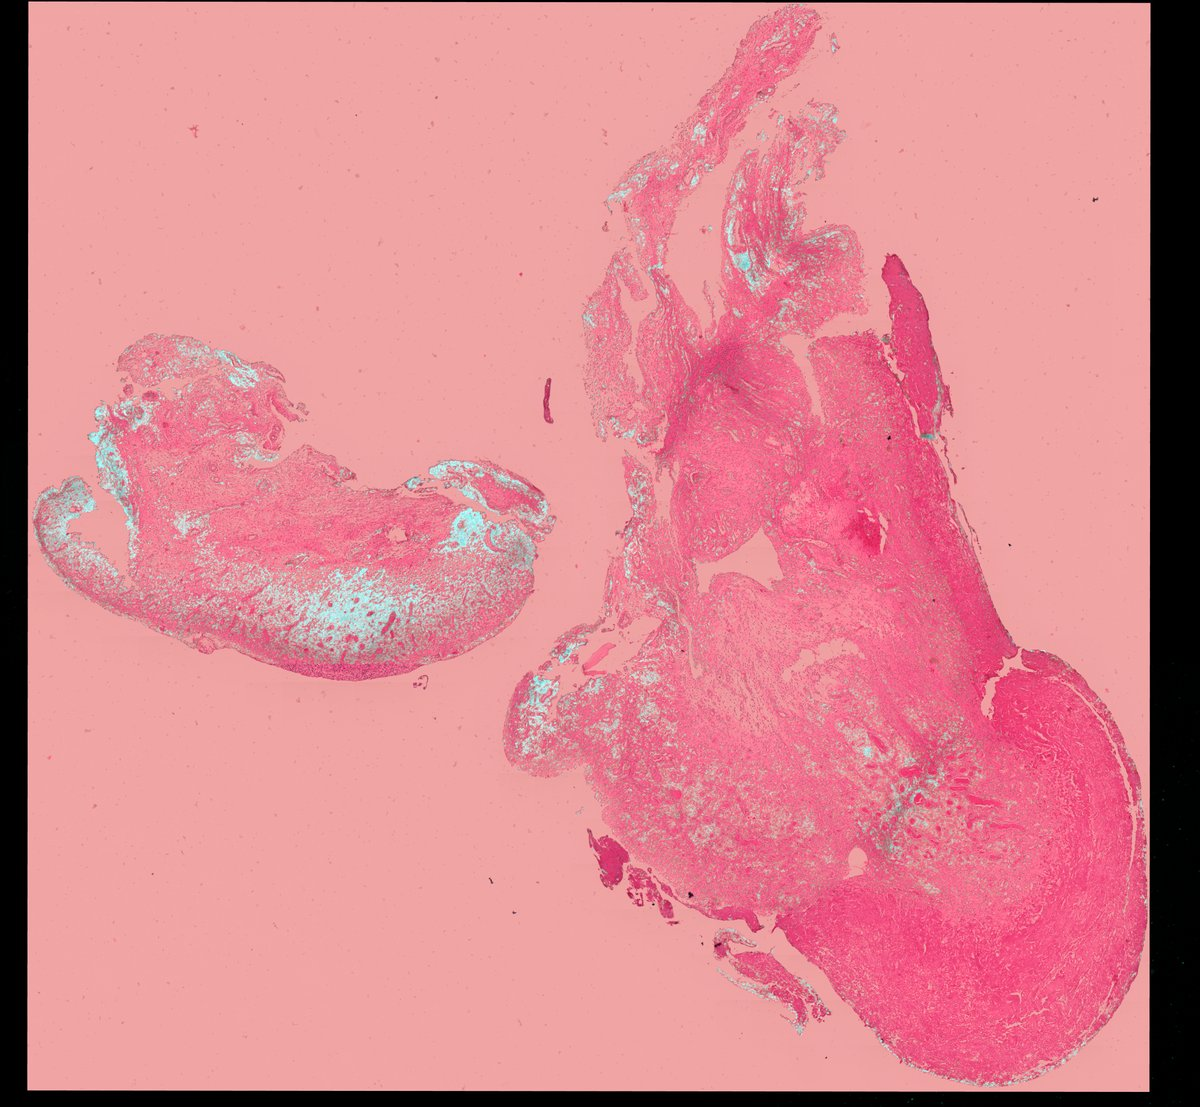

**AP2320a full-slide Palom overlay QC**

The embedded image below is a lightweight thumbnail for GitHub rendering. The full-resolution overlay is written locally to `results/01_palom_registration/figures/AP2320a_palom_full_overlay.png`.

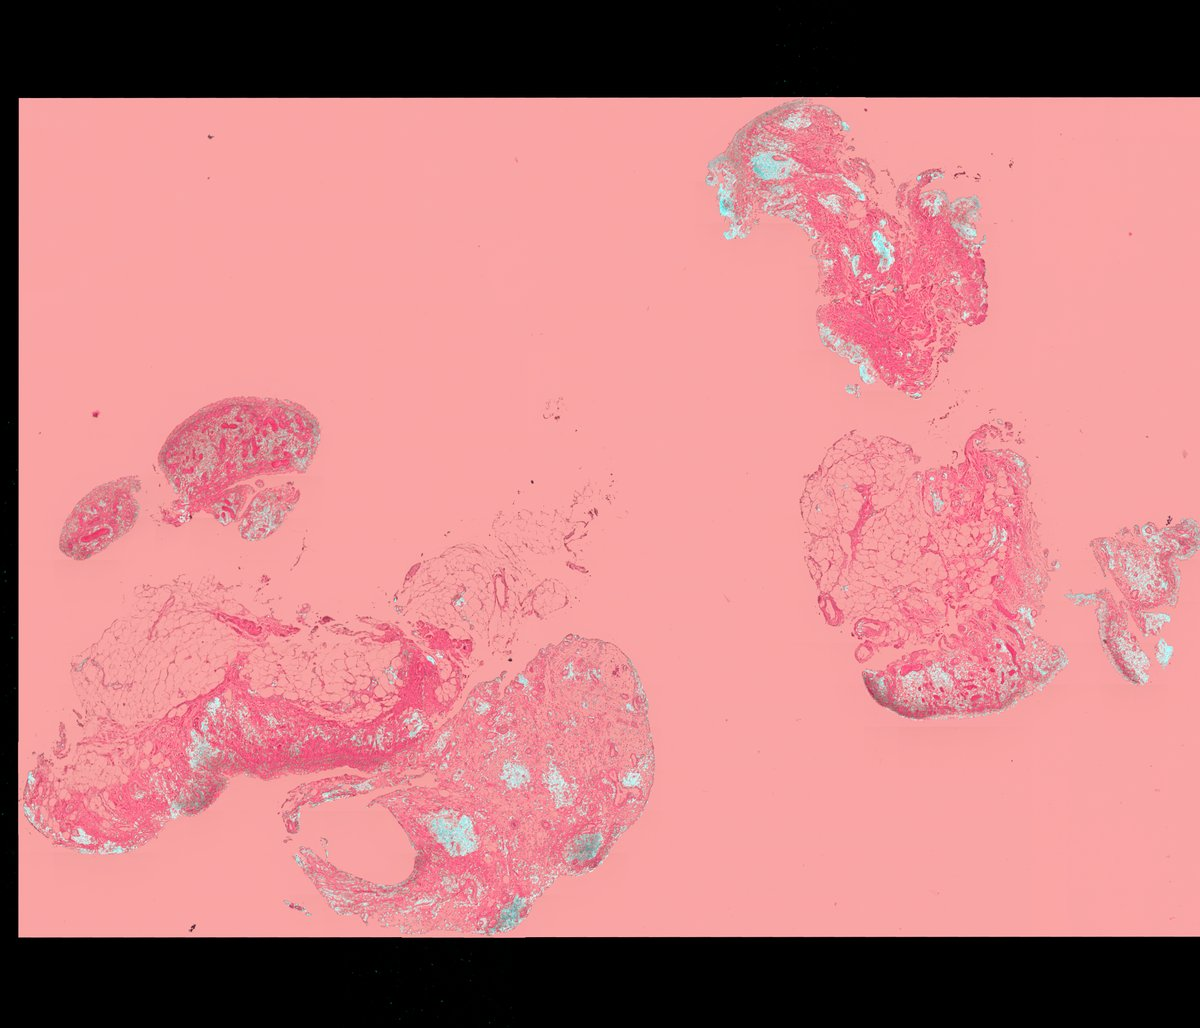

In [7]:
manifest_path = fig_dir / 'palom_registration_qc_manifest.json'
qc_manifest = json.loads(manifest_path.read_text())

from PIL import Image as PILImage
from IPython.display import Image as DisplayImage, Markdown, display

thumb_dir = fig_dir / 'github_thumbnails'
thumb_dir.mkdir(parents=True, exist_ok=True)

def rel_link(path):
    return Path(path).resolve().relative_to(PROJECT.resolve()).as_posix()

for item in qc_manifest:
    full_overlay = Path(item['full_overlay'])
    thumb_path = thumb_dir / f"{item['sample_id']}_palom_full_overlay_thumbnail.jpg"
    if not thumb_path.exists() or thumb_path.stat().st_mtime < full_overlay.stat().st_mtime:
        with PILImage.open(full_overlay) as im:
            im = im.convert('RGB')
            im.thumbnail((1200, 1200), PILImage.Resampling.LANCZOS)
            im.save(thumb_path, quality=85, optimize=True)
    display(Markdown(
        f"**{item['sample_id']} full-slide Palom overlay QC**\n\n"
        f"The embedded image below is a lightweight thumbnail for GitHub rendering. "
        f"The full-resolution overlay is written locally to `{rel_link(full_overlay)}`."
    ))
    display(DisplayImage(filename=str(thumb_path), width=900))


## 6. Output guide

Notebook 1 writes Palom registration outputs under `results/01_palom_registration/`:

- `input_manifest.json`: records the AP0921a/AP2320a H&E and Xenium morphology inputs used for registration.
- `outputs/<sample>/registered_slides/`: Palom registered H&E OME-TIFFs and Palom's registration overlay for each sample.
- `registered_he/`: stable symlinks to the registered H&E files.
- `registered_he_manifest.json`: table of stable registered-H&E paths.
- `figures/<sample>_palom_full_overlay.png`: full-slide H&E/Xenium overlay for registration QC.
- `figures/palom_registration_qc_manifest.json`: overlay manifest listing the full-overlay files.

Cell-boundary inputs are not used in this notebook. Patch boundaries in Notebooks 2 and 3 come from Cellpose `cell_boundaries.csv.gz`.